# Streamflow USGS comparisons 

## 9/1 updates

=== STREAMFLOW DATA ANALYSIS ===
Libraries loaded successfully

=== LOADING ENHANCED DATA FROM ARTIFACTS ===
Loaded artifacts from: artifacts\run_20250901_113434
Using df_combined: 109,626 total sites
Total data source breakdown:
data_source
main          107314
additional      2312
Name: count, dtype: int64
Enhanced dataset loaded successfully

=== FILTERING TO SANTA BARBARA COUNTY ===
Loaded Santa Barbara County boundary for filtering
Filtered from 109,626 total sites to 6,786 Santa Barbara County sites
Santa Barbara data source breakdown:
data_source
main          4992
additional    1794
Name: count, dtype: int64

=== LOADING STREAMFLOW DATA FROM CSV FILES ===
Loading NWIS streamflow measurements...
Loaded NWIS measurements: 1,948 individual measurements
Loading NWIS site summary...
Loaded NWIS sites: 21 unique sites
Filtering enhanced dataset to stream discharge sites...
Historical stream discharge sites: 2,516
Stream discharge sites by data source:
data_source
main          2400
a

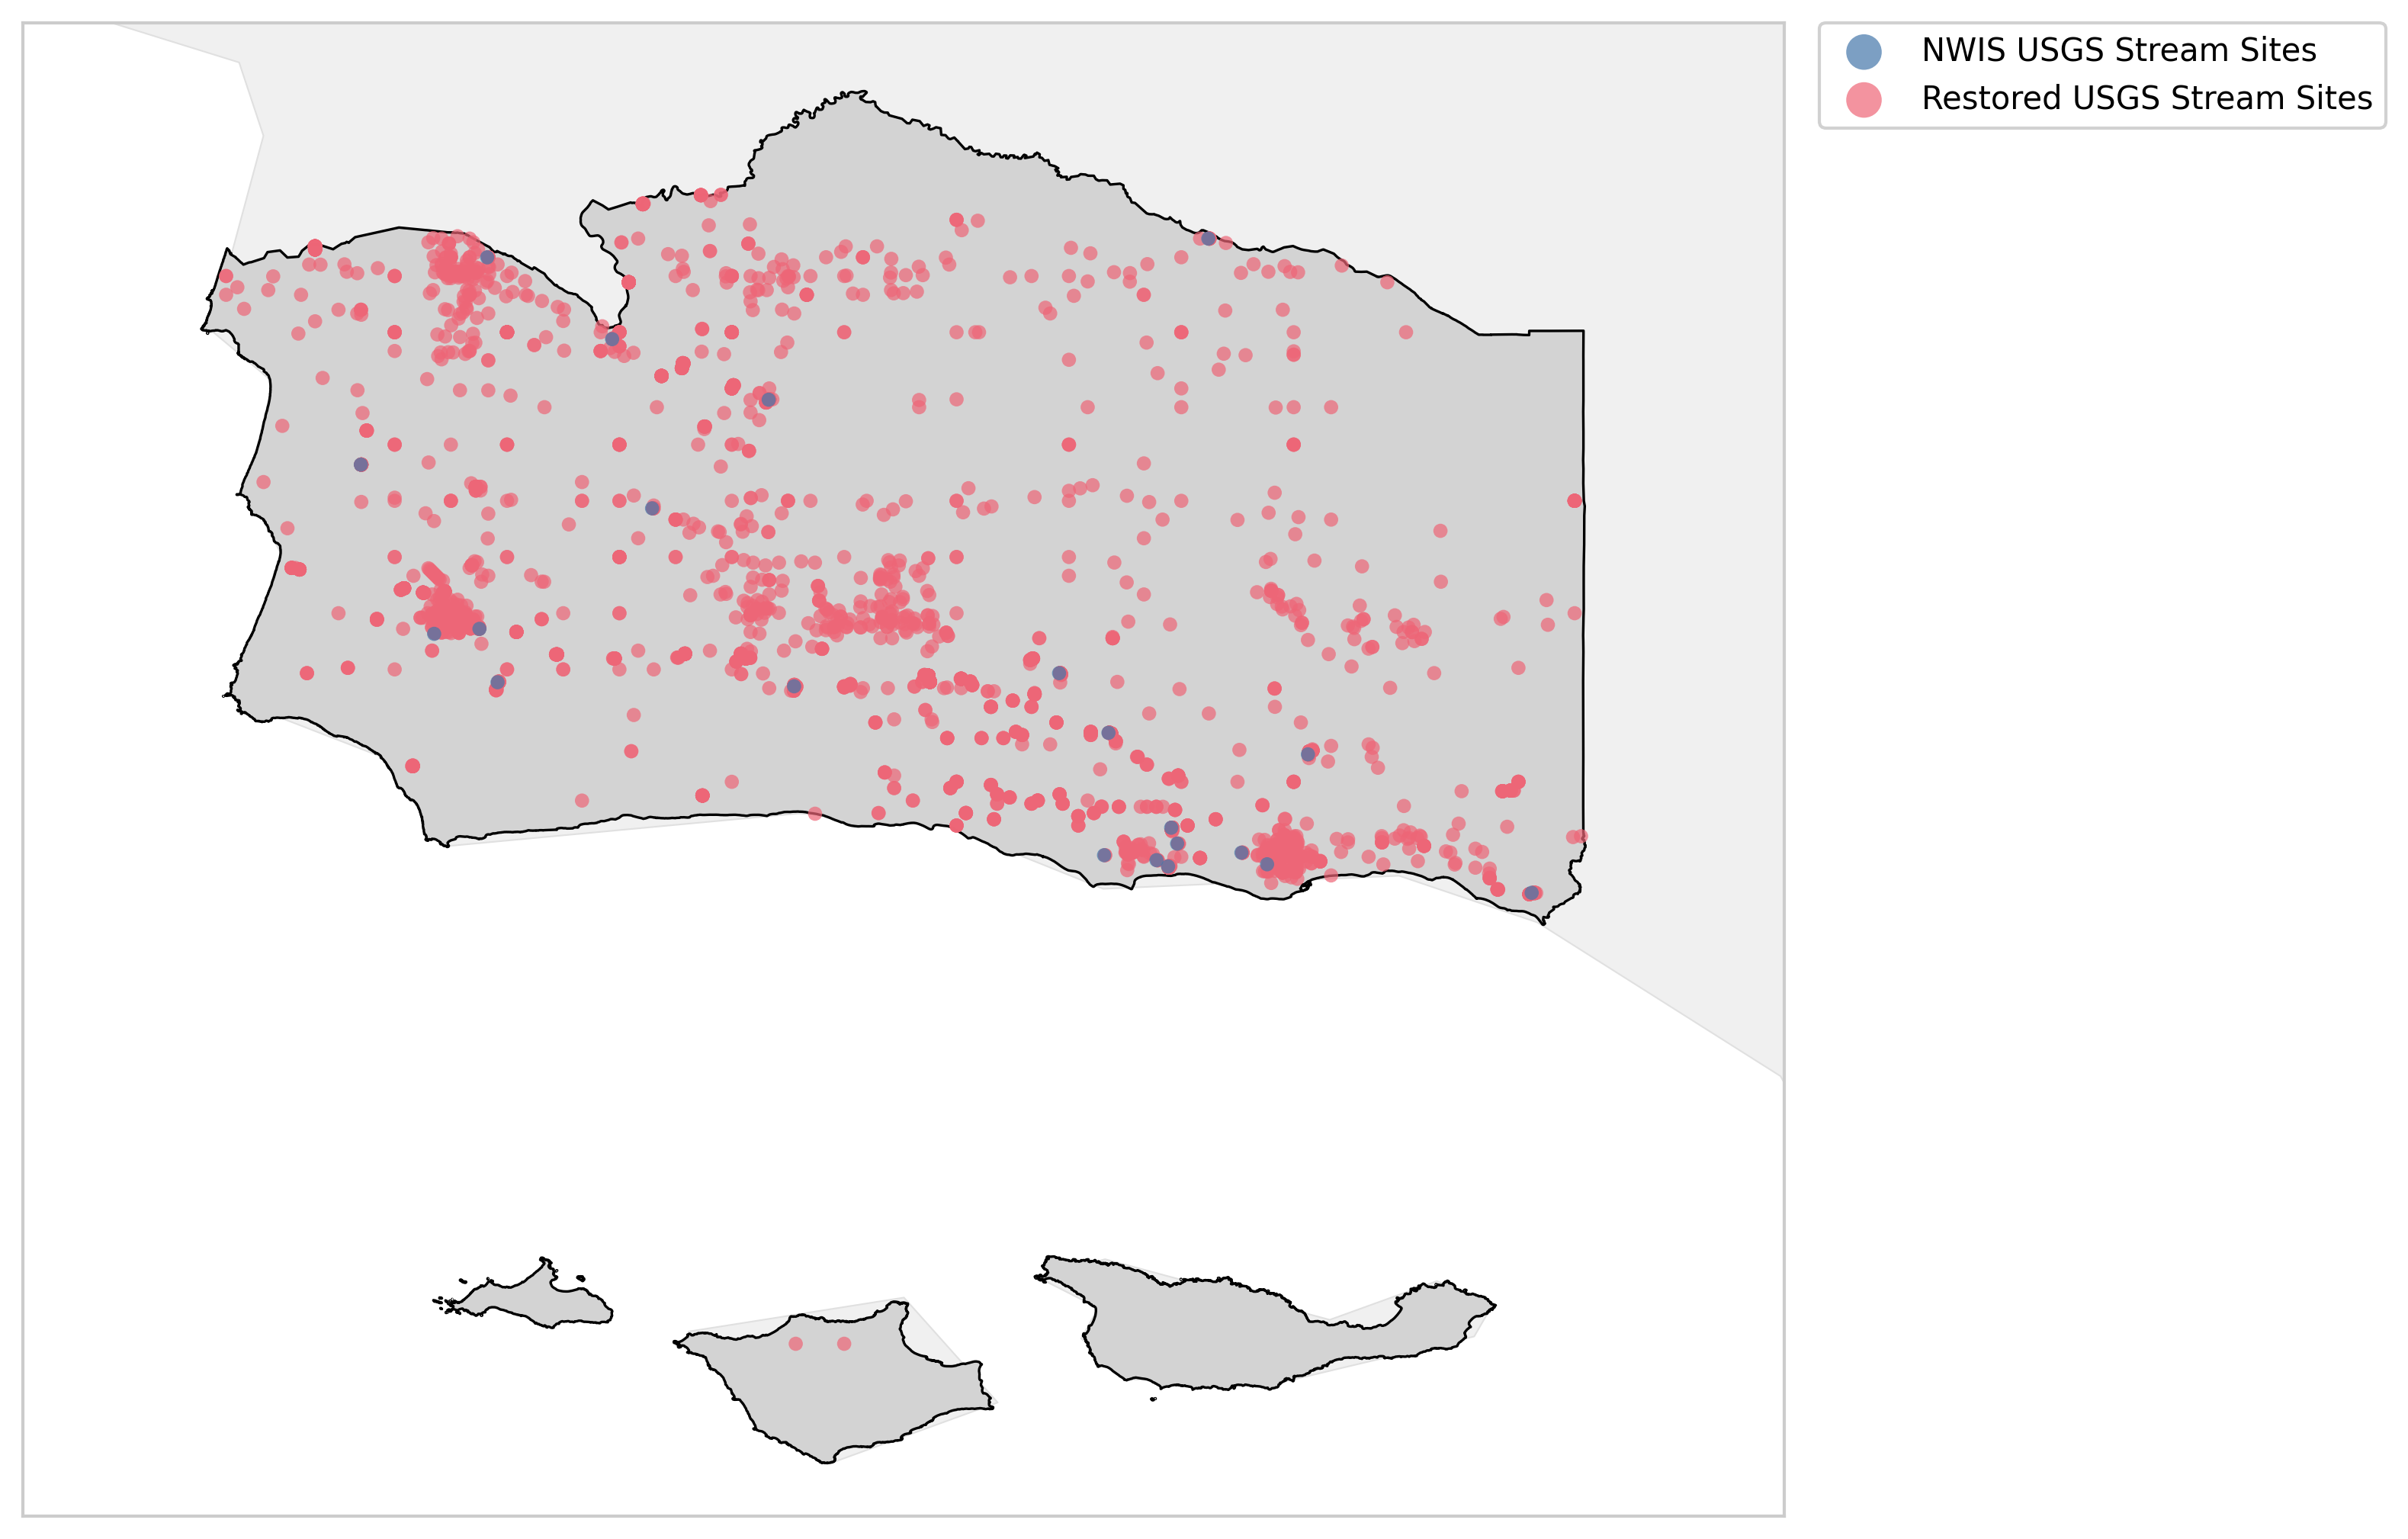


=== CREATING SITE-BASED DECADAL MAP ===
Combined sites data: 2,537
Saved sites decadal map: streamflow_sites_decadal.png


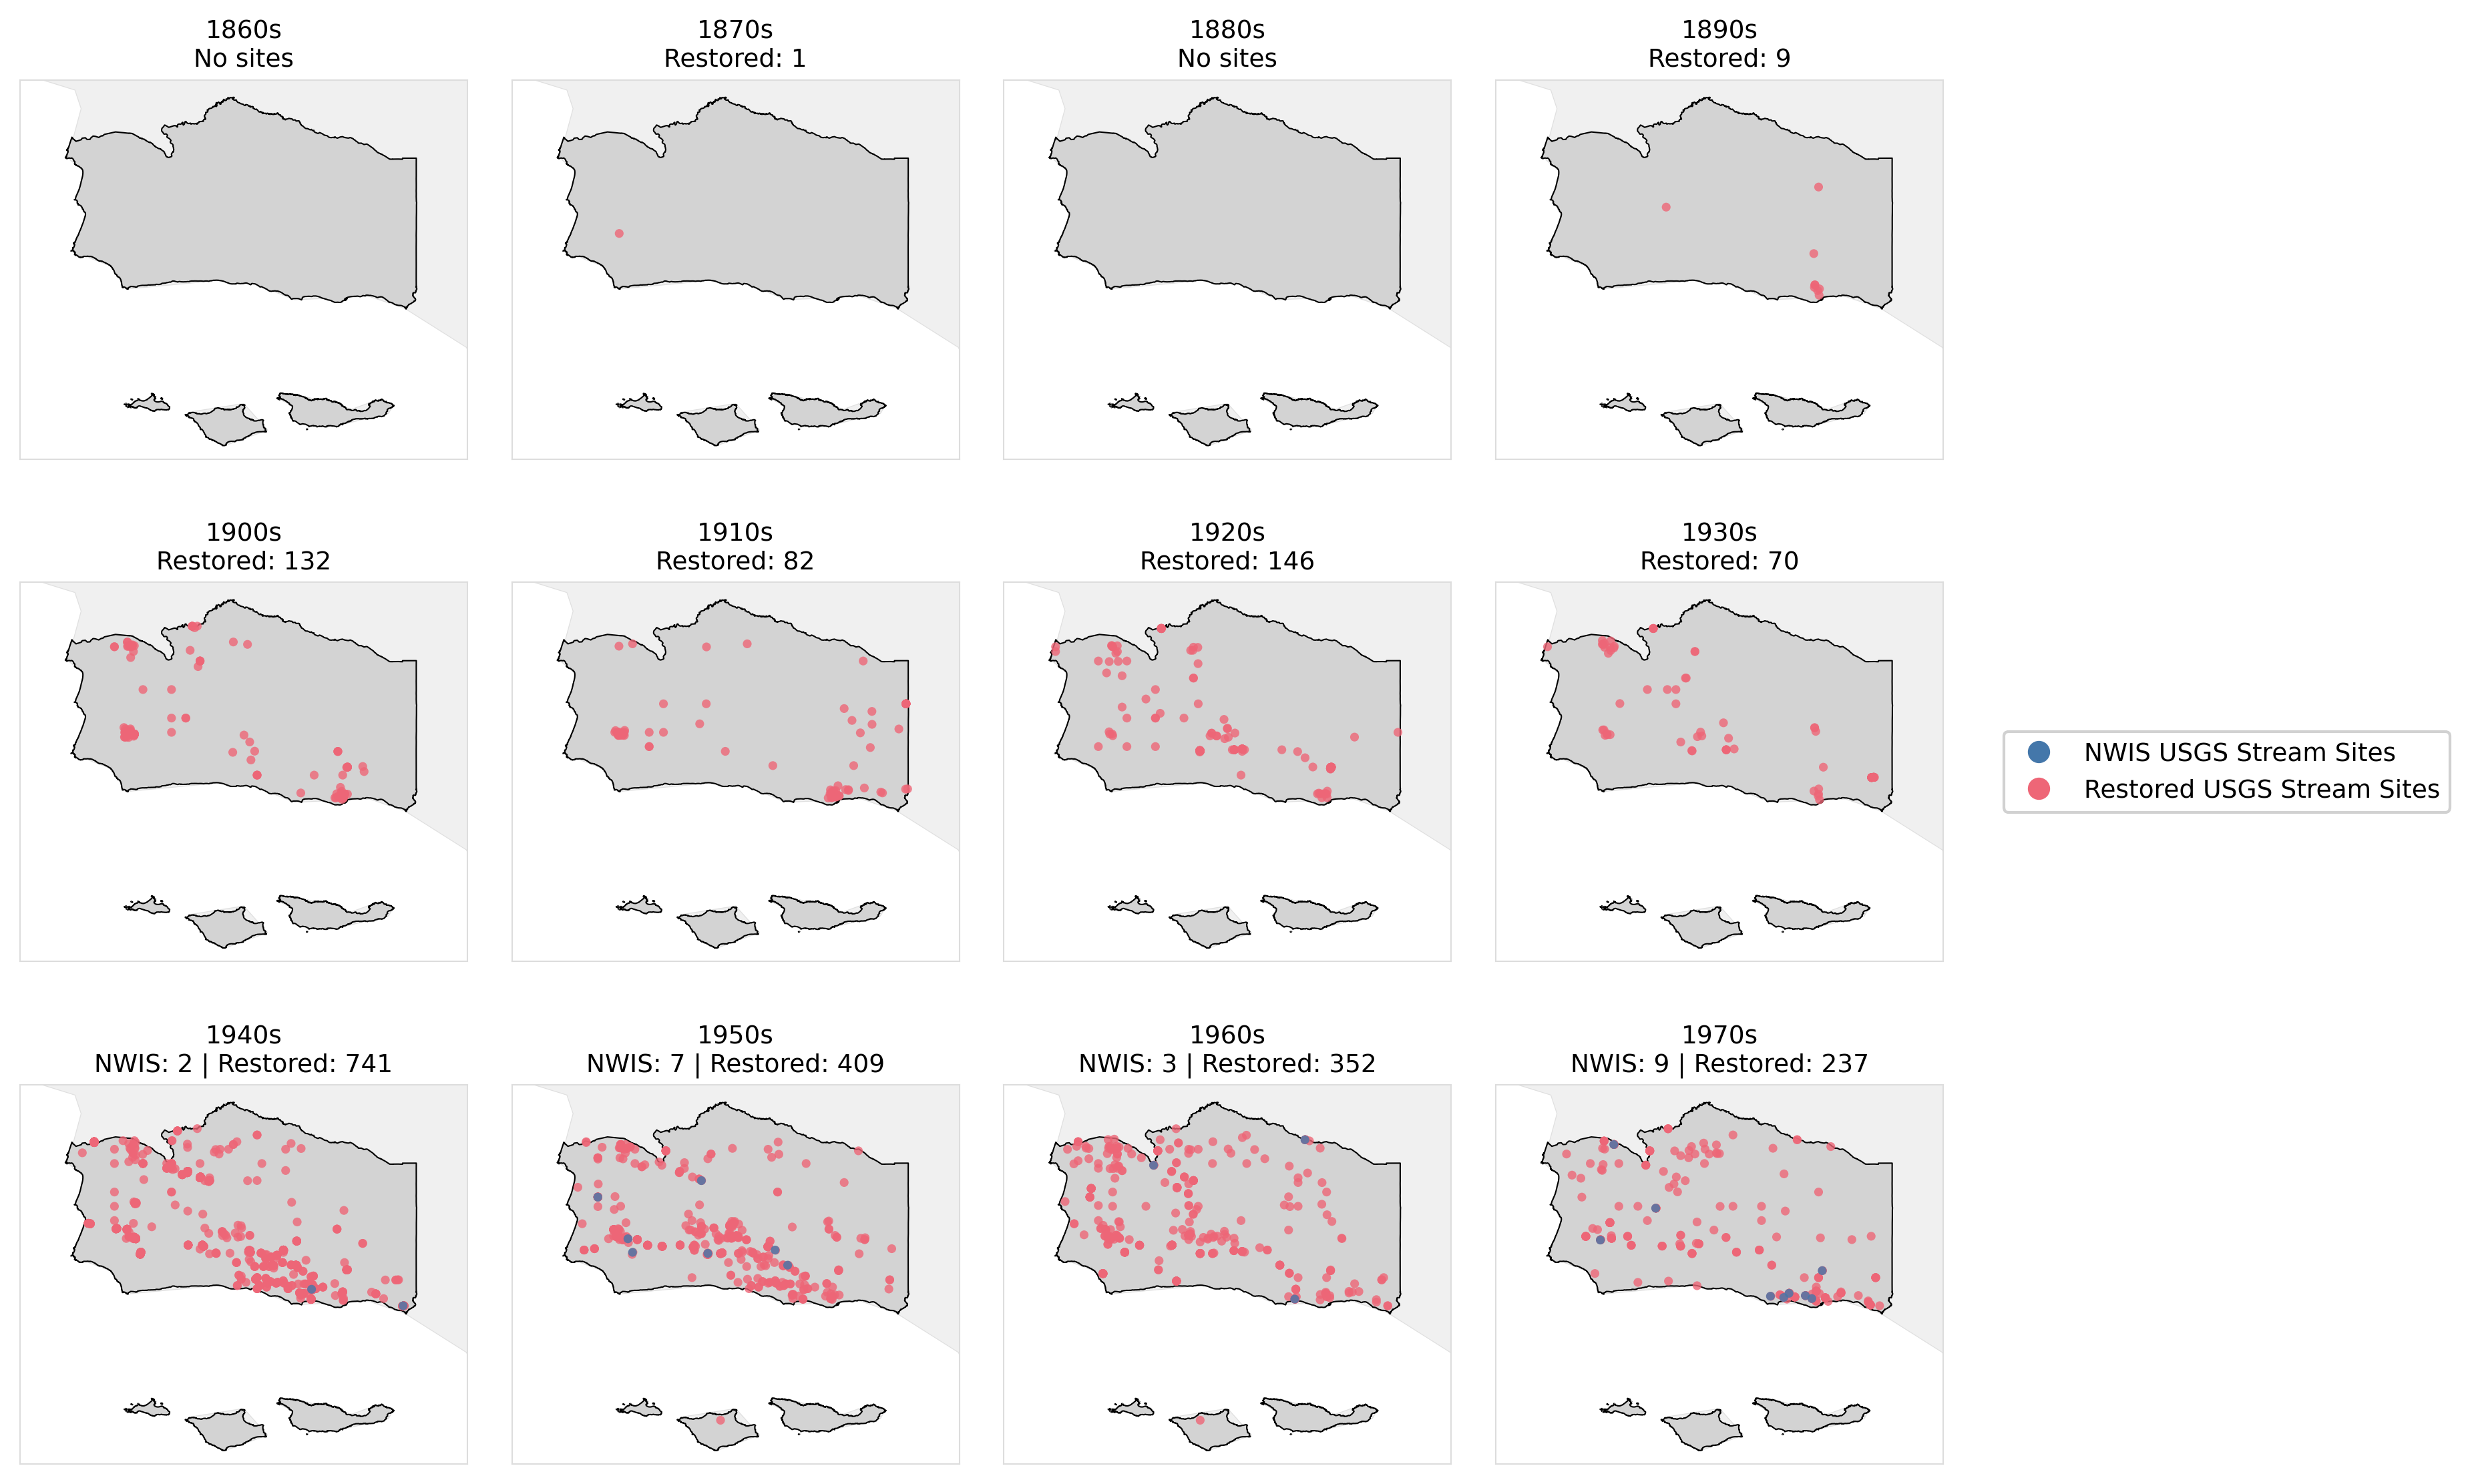


=== SITES DECADAL SUMMARY ===
Sites by decade and data type:
data_type  NWIS USGS  Restored USGS
decade                             
1870.0             0              1
1890.0             0              9
1900.0             0            132
1910.0             0             82
1920.0             0            146
1930.0             0             70
1940.0             2            741
1950.0             7            409
1960.0             3            352
1970.0             9            237

=== ALL MAPS COMPLETED ===
Created 2 streamflow maps:
1. Site-based comparison
2. Site-based decadal with detailed counts

Note: Historical data now includes both original and additional Santa Barbara sites


In [11]:
# ==== USGS Streamflow Analysis and Comparison (UPDATED FOR ADDITIONAL DATA) ====
print("=== STREAMFLOW DATA ANALYSIS ===")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

# ==== Load Enhanced Data from Artifacts ====
print("\n=== LOADING ENHANCED DATA FROM ARTIFACTS ===")

from artifacts_io import load_artifacts

# Load artifacts that include both main and additional data
tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print(f"Loaded artifacts from: {run_dir}")

# Get the combined dataset
if "df_combined" in tables:
    restored_df_all = tables["df_combined"].copy()
    print(f"Using df_combined: {len(restored_df_all):,} total sites")
elif "df" in tables:
    restored_df_all = tables["df"].copy()
    print(f"Using df: {len(restored_df_all):,} total sites")
else:
    # Use the largest table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])
    restored_df_all = tables[everything_key].copy()
    print(f"Using {everything_key}: {len(restored_df_all):,} total sites")

# Check for data source information
if 'data_source' in restored_df_all.columns:
    print("Total data source breakdown:")
    print(restored_df_all['data_source'].value_counts())

print("Enhanced dataset loaded successfully")

# ==== Filter to Santa Barbara County Only ====
print("\n=== FILTERING TO SANTA BARBARA COUNTY ===")

# Load Santa Barbara County boundary first
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
    print("Loaded Santa Barbara County boundary for filtering")
    
    # Create GeoDataFrame for filtering
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in restored_df_all.columns else ['longitude', 'latitude']
    restored_gdf_all = gpd.GeoDataFrame(
        restored_df_all,
        geometry=gpd.points_from_xy(restored_df_all[coord_cols[0]], restored_df_all[coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    # Filter to Santa Barbara County only
    within_sb = restored_gdf_all.within(sb_county_geom)
    restored_df = restored_df_all.loc[within_sb].copy()
    
    print(f"Filtered from {len(restored_df_all):,} total sites to {len(restored_df):,} Santa Barbara County sites")
    
    if 'data_source' in restored_df.columns:
        print("Santa Barbara data source breakdown:")
        print(restored_df['data_source'].value_counts())
    
except FileNotFoundError:
    print("ERROR: County boundary file not found - cannot filter to Santa Barbara County")
    raise
except Exception as e:
    print(f"ERROR filtering to Santa Barbara County: {e}")
    raise

# ==== Load Streamflow Data from CSV Files ====
print("\n=== LOADING STREAMFLOW DATA FROM CSV FILES ===")

# Define file paths - Updated to use your measurement data
nwis_measurements_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv")
nwis_sites_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_sites_for_mapping.csv")

try:
    # Load NWIS measurement data (individual measurements)
    print("Loading NWIS streamflow measurements...")
    nwis_measurements = pd.read_csv(nwis_measurements_csv)
    print(f"Loaded NWIS measurements: {len(nwis_measurements):,} individual measurements")
    
    # Parse dates and extract year
    nwis_measurements['measurement_dt'] = pd.to_datetime(nwis_measurements['measurement_dt'], errors='coerce')
    nwis_measurements['year'] = nwis_measurements['measurement_dt'].dt.year
    nwis_measurements['decade'] = (nwis_measurements['year'] // 10) * 10
    
    # Load NWIS site summary (unique sites)
    print("Loading NWIS site summary...")
    nwis_sites = pd.read_csv(nwis_sites_csv)
    print(f"Loaded NWIS sites: {len(nwis_sites):,} unique sites")
    
    # Filter to stream discharge sites only from the enhanced dataset
    print("Filtering enhanced dataset to stream discharge sites...")
    historical_streams = restored_df[restored_df['water_type_clean'] == 'Stream discharge'].copy()
    print(f"Historical stream discharge sites: {len(historical_streams):,}")
    
    # Show breakdown by data source if available
    if 'data_source' in historical_streams.columns:
        print("Stream discharge sites by data source:")
        print(historical_streams['data_source'].value_counts())
    
    # Add decade column for historical data
    if 'year_start' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['year_start'] // 10) * 10
    elif 'start_year' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['start_year'] // 10) * 10
    else:
        print("Warning: No start year column found in historical data")
        historical_streams['decade'] = 1940
    
    print(f"Data loaded successfully")
    
    # We need coordinates for NWIS sites - get them from NWIS web services
    print("\nGetting coordinates for NWIS sites...")
    from dataretrieval import nwis as nwis_service
    
    # Get unique site numbers
    unique_sites = nwis_sites['site_no'].unique()
    print(f"Getting coordinates for {len(unique_sites)} NWIS sites...")
    
    # Get site information including coordinates
    site_info = nwis_service.get_info(sites=unique_sites.tolist())
    site_coords = site_info[0][['site_no', 'dec_lat_va', 'dec_long_va']].copy()
    site_coords = site_coords.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude'})
    
    # Convert site_no to string in ALL DataFrames BEFORE merging
    print("Converting site_no columns to consistent data types...")
    nwis_sites['site_no'] = nwis_sites['site_no'].astype(str)
    site_coords['site_no'] = site_coords['site_no'].astype(str)
    nwis_measurements['site_no'] = nwis_measurements['site_no'].astype(str)
    
    # NOW do the merges
    print("Merging coordinate data...")
    nwis_sites_with_coords = nwis_sites.merge(site_coords, on='site_no', how='left')
    
    # Create GeoDataFrames for sites - use processed coordinate columns
    coord_cols = ['longitude', 'latitude']  # from NWIS
    historical_coord_cols = ['lon_combined', 'lat_combined']  # from your processing
    if 'longitude' not in historical_streams.columns and 'lon_combined' in historical_streams.columns:
        historical_coord_cols = ['lon_combined', 'lat_combined']
    elif 'longitude' in historical_streams.columns:
        historical_coord_cols = ['longitude', 'latitude']
    
    nwis_sites_gdf = gpd.GeoDataFrame(
        nwis_sites_with_coords,
        geometry=gpd.points_from_xy(nwis_sites_with_coords['longitude'], nwis_sites_with_coords['latitude']),
        crs="EPSG:4326"
    )
    nwis_sites_gdf['data_type'] = 'NWIS USGS'
    
    # Create GeoDataFrame for historical sites using correct coordinate columns
    historical_sites_gdf = gpd.GeoDataFrame(
        historical_streams,
        geometry=gpd.points_from_xy(historical_streams[historical_coord_cols[0]], historical_streams[historical_coord_cols[1]]),
        crs="EPSG:4326"
    )
    historical_sites_gdf['data_type'] = 'Restored USGS'

except Exception as e:
    print(f"ERROR: {e}")
    print("Check file paths and ensure dataretrieval package is installed")

print(f"Created GeoDataFrames successfully")
print(f"  - NWIS sites: {len(nwis_sites_gdf):,}")
print(f"  - Historical sites (enhanced): {len(historical_sites_gdf):,}")

# ==== Site Density (sites per km²) ====
print("\n=== SITE DENSITY (SITES PER KM²) ===")
try:
    # Use an equal-area projection for correct area (EPSG:5070 = NAD83 / Conus Albers)
    if 'sb_county' not in globals() or sb_county is None or len(sb_county) == 0:
        raise ValueError("Santa Barbara County boundary (sb_county) not available")

    sb_eq = sb_county.to_crs(5070)
    # area() returns m² in projected CRS; convert to km²
    sb_area_km2 = float(sb_eq.geometry.area.sum()) / 1e6

    # Unique site counts (adjust IDs if you prefer a different uniqueness definition)
    nwis_count = nwis_sites_gdf['site_no'].astype(str).nunique()
    hist_count = historical_sites_gdf['id_page_number'].astype(str).nunique()

    # Densities
    nwis_density = nwis_count / sb_area_km2 if sb_area_km2 > 0 else np.nan
    hist_density = hist_count / sb_area_km2 if sb_area_km2 > 0 else np.nan

    print(f"Santa Barbara County area: {sb_area_km2:,.2f} km²")
    print(f"NWIS sites: {nwis_count:,}  → density: {nwis_density:.6f} sites/km²")
    print(f"Historical sites: {hist_count:,}  → density: {hist_density:.6f} sites/km²")

    # Save a quick summary to CSV
    density_df = pd.DataFrame({
        'dataset': ['NWIS sites', 'Historical sites'],
        'count': [nwis_count, hist_count],
        'area_km2': [sb_area_km2, sb_area_km2],
        'density_sites_per_km2': [nwis_density, hist_density]
    })
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    outfile = output_dir / "site_density_summary.csv"
    density_df.to_csv(outfile, index=False)
    print(f"Saved density summary to: {outfile}")

except Exception as e:
    print(f"ERROR computing densities: {e}")


# ==== PROPER EXTENT CALCULATION (Same as working script) ====
print("=== CALCULATING PROPER MAP EXTENT ===")

# Combine all data for extent calculation
all_mapping_data = []
if 'nwis_sites_gdf' in locals() and len(nwis_sites_gdf) > 0:
    all_mapping_data.append(nwis_sites_gdf)
if 'historical_sites_gdf' in locals() and len(historical_sites_gdf) > 0:
    all_mapping_data.append(historical_sites_gdf)

if all_mapping_data:
    # Combine all data to get proper bounds
    combined_data = gpd.GeoDataFrame(pd.concat(all_mapping_data, ignore_index=True))
    
    # Get bounds from the ACTUAL DATA (not the county shapefile)
    minx, miny, maxx, maxy = combined_data.total_bounds
    
    # Calculate proportional padding (same as working script)
    pad_lon = max(0.01, (maxx - minx) * 0.15)  # 15% padding
    pad_lat = max(0.01, (maxy - miny) * 0.15)
    
    # Set consistent extent variables
    SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (
        minx - pad_lon, 
        miny - pad_lat, 
        maxx + pad_lon, 
        maxy + pad_lat
    )
    
    print(f"Data extent: {minx:.3f}, {miny:.3f}, {maxx:.3f}, {maxy:.3f}")
    print(f"Map extent with padding: {SB_XMIN:.3f}, {SB_YMIN:.3f}, {SB_XMAX:.3f}, {SB_YMAX:.3f}")
else:
    print("Warning: No data found for extent calculation")
    # Fallback to county bounds if no data
    if 'sb_county' in locals():
        bounds = sb_county.total_bounds
        SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = bounds
    else:
        # Default Santa Barbara area
        SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (-120.8, 34.2, -119.4, 34.9)

# Create output directory
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# ==== Map 1: Site-Based Comparison Map ====
print("\n=== CREATING SITE-BASED COMPARISON MAP ===")

def create_comparison_map(nwis_data, historical_data, title_suffix, filename):
    """Create a comparison map with proper extent"""
    
    # Calculate aspect ratio based on data bounds (not arbitrary)
    width = SB_XMAX - SB_XMIN
    height = SB_YMAX - SB_YMIN
    aspect_ratio = width / height
    fig, ax = plt.subplots(figsize=(10, 10/aspect_ratio), dpi=300)
    
    # Add California context
    try:
        ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
        if os.path.exists(ca_context_path):
            ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
            ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
            gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                ax=ax, color="#f0f0f0", edgecolor="#e0e0e0", linewidth=0.5, zorder=0
            )
    except Exception:
        pass
    
    # Plot county boundary
    if 'SB_COUNTY_GDF' in globals() and SB_COUNTY_GDF is not None:
        SB_COUNTY_GDF.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.8, zorder=1)
    
    # Plot data
    nwis_data.plot(ax=ax, color='#4477AA', markersize=20, alpha=0.7, edgecolor='none', zorder=3, label='NWIS USGS Stream Sites')
    historical_data.plot(ax=ax, color='#EE6677', markersize=20, alpha=0.7, edgecolor='none', zorder=2, label='Restored USGS Stream Sites')
    
    # CONSISTENT extent setting (no arbitrary extensions)
    ax.set_xlim(SB_XMIN, SB_XMAX)
    ax.set_ylim(SB_YMIN, SB_YMAX)
    ax.set_aspect('equal')
    
    # Styling
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.0)
    
    # Legend
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, 
             markerscale=2.5, frameon=True, fancybox=True, framealpha=0.9)
    
    plt.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()

if 'nwis_sites_gdf' in locals() and 'historical_sites_gdf' in locals():
    create_comparison_map(nwis_sites_gdf, historical_sites_gdf, "Sites", "streamflow_sites_comparison.png")

# ==== Map 2: Site-Based Decadal Map ====
print("\n=== CREATING SITE-BASED DECADAL MAP ===")

def create_decadal_map(nwis_data, historical_data, title_suffix, filename):
    """Create a decadal map with detailed site counts in titles"""
    # Combine datasets
    nwis_subset = nwis_data[['geometry', 'decade', 'data_type']].copy()
    historical_subset = historical_data[['geometry', 'decade', 'data_type']].copy()
    all_data = gpd.GeoDataFrame(pd.concat([nwis_subset, historical_subset], ignore_index=True))
    
    print(f"Combined {title_suffix.lower()} data: {len(all_data):,}")
    
    # Define decades
    decades = list(range(1860, 1980, 10))
    
    # Set up plot
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), dpi=300)
    axes = axes.flatten()
    
    plt.subplots_adjust(left=0.05, bottom=0.05, right=0.85, top=0.95, wspace=0.1, hspace=0.15)
    
    colors = {'Restored USGS': '#EE6677', 'NWIS USGS': '#4477AA'}
    
    for i, decade in enumerate(decades):
        ax = axes[i]
        decade_data = all_data[all_data['decade'] == decade]
        
        # Add California context
        try:
            ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
            if os.path.exists(ca_context_path):
                ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
                ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
                gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                    ax=ax, color="#f0f0f0", edgecolor="#e0e0e0", linewidth=0.3, zorder=0
                )
        except Exception:
            pass
        
        # Plot county boundary
        if SB_COUNTY_GDF is not None:
            SB_COUNTY_GDF.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5, zorder=1)
        
        # Plot data by type
        for data_type, color in [('NWIS USGS', colors['NWIS USGS']), ('Restored USGS', colors['Restored USGS'])]:
            type_data = decade_data[decade_data['data_type'] == data_type]
            if len(type_data) > 0:
                type_data.plot(ax=ax, color=color, markersize=10, alpha=0.8, edgecolor='none', 
                             linewidth=0, zorder=3 if data_type == 'NWIS USGS' else 2)
        
        # CONSISTENT extent setting (same for all panels)
        ax.set_xlim(SB_XMIN, SB_XMAX)
        ax.set_ylim(SB_YMIN, SB_YMAX)
        ax.set_aspect('equal')
        
        # Create detailed title with counts broken down by data type
        nwis_count = len(decade_data[decade_data['data_type'] == 'NWIS USGS'])
        restored_count = len(decade_data[decade_data['data_type'] == 'Restored USGS'])
        
        # Format title with breakdown
        if nwis_count > 0 and restored_count > 0:
            title = f"{decade}s\nNWIS: {nwis_count} | Restored: {restored_count}"
        elif nwis_count > 0:
            title = f"{decade}s\nNWIS: {nwis_count}"
        elif restored_count > 0:
            title = f"{decade}s\nRestored: {restored_count}"
        else:
            title = f"{decade}s\nNo sites"
        
        ax.set_title(title, fontsize=9, pad=5)
        
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#dddddd')
            spine.set_linewidth(0.5)
    
    # Legend
    legend_elements = [
        Line2D([0],[0], marker='o', linestyle='', markerfacecolor=colors['NWIS USGS'], 
               markeredgecolor='none', markersize=8, label='NWIS USGS Stream Sites'),
        Line2D([0],[0], marker='o', linestyle='', markerfacecolor=colors['Restored USGS'], 
               markeredgecolor='none', markersize=8, label='Restored USGS Stream Sites')
    ]
    
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.87, 0.5),
               frameon=True, fancybox=True, framealpha=0.9, fontsize=9)
    
    plt.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
    print(f"Saved {title_suffix.lower()} decadal map: {filename}")
    plt.show()
    
    # Print summary
    print(f"\n=== {title_suffix.upper()} DECADAL SUMMARY ===")
    decade_summary = all_data.groupby(['decade', 'data_type']).size().unstack(fill_value=0)
    print(f"{title_suffix} by decade and data type:")
    print(decade_summary)

if 'nwis_sites_gdf' in locals() and 'historical_sites_gdf' in locals():
    create_decadal_map(nwis_sites_gdf, historical_sites_gdf, "Sites", "streamflow_sites_decadal.png")

print("\n=== ALL MAPS COMPLETED ===")
print("Created 2 streamflow maps:")
print("1. Site-based comparison")
print("2. Site-based decadal with detailed counts")
print(f"\nNote: Historical data now includes both original and additional Santa Barbara sites")

## Summary figures of counts and cumulative 

=== CREATING TWO-PANEL STREAMFLOW SITES TIMELINE ===
Using streamflow datasets from previous analysis...
Combined streamflow data: 2,537 sites
  - NWIS USGS: 21
  - Restored USGS: 2,516
Saved two-panel streamflow figure: output\streamflow_sites_two_panel.png


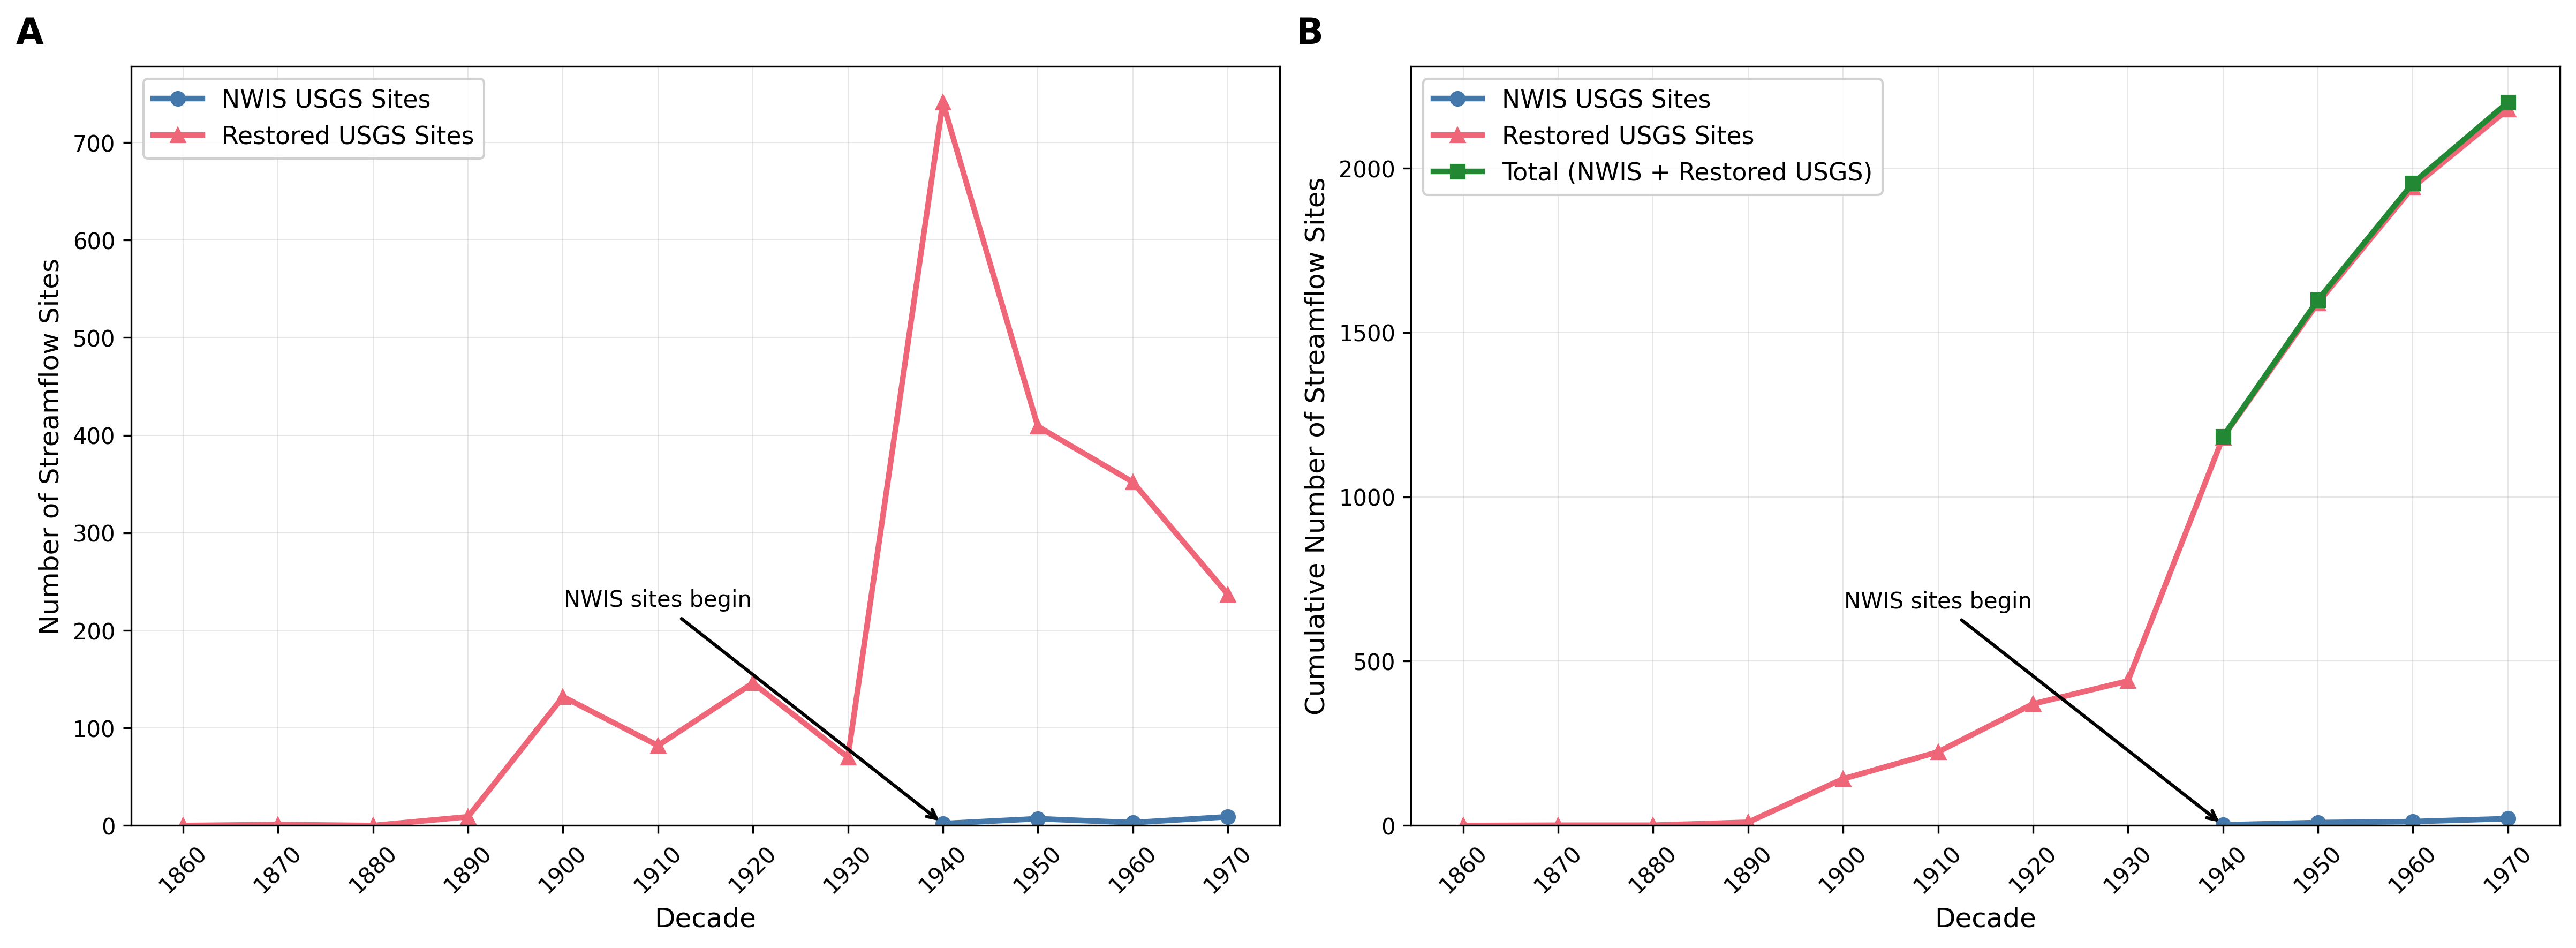


=== STREAMFLOW SUMMARY STATISTICS ===
Per-decade counts:
Decade  NWIS USGS  Restored USGS
  1860          0              0
  1870          0              1
  1880          0              0
  1890          0              9
  1900          0            132
  1910          0             82
  1920          0            146
  1930          0             70
  1940          2            741
  1950          7            409
  1960          3            352
  1970          9            237

Cumulative totals:
Decade  NWIS USGS  Restored USGS  Total
  1860          0              0      0
  1870          0              1      1
  1880          0              1      1
  1890          0             10     10
  1900          0            142    142
  1910          0            224    224
  1920          0            370    370
  1930          0            440    440
  1940          2           1181   1183
  1950          9           1590   1599
  1960         12           1942   1954
  1970       

In [10]:
# ==== Create Two-Panel Figure: Streamflow Sites Over Time ====
print("=== CREATING TWO-PANEL STREAMFLOW SITES TIMELINE ===")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the streamflow datasets from the previous script
if 'nwis_sites_gdf' in globals() and 'historical_sites_gdf' in globals():
    print("Using streamflow datasets from previous analysis...")
    
    # Define decade range (1860s to 1970s) - same as original script
    decades = list(range(1860, 1980, 10))
    
    # Prepare NWIS streamflow sites data
    nwis_sites_subset = nwis_sites_gdf[['geometry', 'decade', 'data_type']].copy() if 'decade' in nwis_sites_gdf.columns else nwis_sites_gdf[['geometry', 'data_type']].copy()
    
    # Add decade column to NWIS sites if not present (use a reasonable default since NWIS is modern)
    if 'decade' not in nwis_sites_subset.columns:
        nwis_sites_subset['decade'] = 1970  # Default NWIS to 1970s
    
    # Prepare historical streamflow sites data
    historical_sites_subset = historical_sites_gdf[['geometry', 'decade', 'data_type']].copy()
    
    # Combine streamflow datasets
    all_streamflow_data = gpd.GeoDataFrame(pd.concat([nwis_sites_subset, historical_sites_subset], ignore_index=True))
    
    print(f"Combined streamflow data: {len(all_streamflow_data):,} sites")
    print(f"  - NWIS USGS: {len(nwis_sites_subset):,}")
    print(f"  - Restored USGS: {len(historical_sites_subset):,}")
    
    # Count sites by decade and data type
    decade_counts = all_streamflow_data.groupby(['decade', 'data_type']).size().unstack(fill_value=0)
    
    # Ensure all decades are represented (fill missing with 0)
    decade_counts = decade_counts.reindex(decades, fill_value=0)
    
    # Calculate cumulative counts
    nwis_cumulative = decade_counts['NWIS USGS'].cumsum() if 'NWIS USGS' in decade_counts.columns else pd.Series(0, index=decades)
    restored_cumulative = decade_counts['Restored USGS'].cumsum() if 'Restored USGS' in decade_counts.columns else pd.Series(0, index=decades)
    total_cumulative = nwis_cumulative + restored_cumulative
    
    # Get non-cumulative counts (actual counts per decade)
    nwis_counts = decade_counts['NWIS USGS'] if 'NWIS USGS' in decade_counts.columns else pd.Series(0, index=decades)
    restored_counts = decade_counts['Restored USGS'] if 'Restored USGS' in decade_counts.columns else pd.Series(0, index=decades)
    
    # Use the same color palette from the streamflow script
    colors = {
        'NWIS USGS': '#4477AA',      # Blue
        'Restored USGS': '#EE6677',  # Red
        'Total': '#228833'           # Green for total
    }
    
    # Create the two-panel figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    
    # ==== PANEL A: NON-CUMULATIVE COUNTS ====
    # For NWIS, only plot from where data actually exists (remove leading zeros)
    nwis_nonzero_mask = nwis_counts > 0
    nwis_decades_filtered = np.array(decades)[nwis_nonzero_mask]
    nwis_counts_filtered = nwis_counts[nwis_nonzero_mask]
    
    # Plot NWIS line only where data exists
    if len(nwis_counts_filtered) > 0:
        ax1.plot(nwis_decades_filtered, nwis_counts_filtered, 
                 color=colors['NWIS USGS'], 
                 linewidth=2.5, 
                 marker='o', 
                 markersize=6,
                 label='NWIS USGS Sites')
    
    # Plot restored sites (full timeline)
    ax1.plot(decades, restored_counts, 
             color=colors['Restored USGS'], 
             linewidth=2.5, 
             marker='^', 
             markersize=6,
             label='Restored USGS Sites')
    
    # Formatting for Panel A
    ax1.set_xlabel('Decade', fontsize=12)
    ax1.set_ylabel('Number of Streamflow Sites', fontsize=12)
    
    # Set x-axis ticks
    ax1.set_xticks(decades)
    ax1.set_xticklabels([str(d) for d in decades], rotation=45)
    
    # Grid and styling
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax1.set_ylim(bottom=0)
    
    # Add annotation for NWIS start (Panel A)
    nwis_start_decade_a = None
    for decade in decades:
        if nwis_counts[decade] > 0:
            nwis_start_decade_a = decade
            break
    
    if nwis_start_decade_a is not None:
        y_value_a = nwis_counts[nwis_start_decade_a]
        ax1.annotate('NWIS sites begin', 
                    xy=(nwis_start_decade_a, y_value_a),
                    xytext=(nwis_start_decade_a - 30, y_value_a + max(max(nwis_counts), max(restored_counts)) * 0.3),
                    fontsize=10,
                    ha='center',
                    arrowprops=dict(arrowstyle='->', 
                                  color='black',
                                  lw=1.5))
    
    # Panel A label
    ax1.text(-0.1, 1.02, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='bottom')
    
    # ==== PANEL B: CUMULATIVE COUNTS ====
    # For NWIS cumulative, only plot from where data actually exists
    nwis_cumulative_nonzero_mask = nwis_cumulative > 0
    nwis_cumulative_decades_filtered = np.array(decades)[nwis_cumulative_nonzero_mask]
    nwis_cumulative_filtered = nwis_cumulative[nwis_cumulative_nonzero_mask]
    
    # Plot NWIS cumulative line only where data exists
    if len(nwis_cumulative_filtered) > 0:
        ax2.plot(nwis_cumulative_decades_filtered, nwis_cumulative_filtered, 
                color=colors['NWIS USGS'], 
                linewidth=2.5, 
                marker='o', 
                markersize=6,
                label='NWIS USGS Sites')
    
    # Plot restored cumulative (full timeline)
    ax2.plot(decades, restored_cumulative, 
            color=colors['Restored USGS'], 
            linewidth=2.5, 
            marker='^', 
            markersize=6,
            label='Restored USGS Sites')
    
    # For total, only plot from where NWIS actually starts (to avoid misleading total line)
    total_cumulative_filtered = total_cumulative[nwis_cumulative_nonzero_mask] if len(nwis_cumulative_filtered) > 0 else total_cumulative
    total_decades_filtered = nwis_cumulative_decades_filtered if len(nwis_cumulative_filtered) > 0 else decades
    
    ax2.plot(total_decades_filtered, total_cumulative_filtered, 
            color=colors['Total'], 
            linewidth=2.5, 
            marker='s', 
            markersize=6,
            label='Total (NWIS + Restored USGS)')
    
    # Formatting for Panel B
    ax2.set_xlabel('Decade', fontsize=12)
    ax2.set_ylabel('Cumulative Number of Streamflow Sites', fontsize=12)
    
    # Set x-axis ticks
    ax2.set_xticks(decades)
    ax2.set_xticklabels([str(d) for d in decades], rotation=45)
    
    # Grid and styling
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.set_axisbelow(True)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax2.set_ylim(bottom=0)
    
    # Add annotation for NWIS start (Panel B)
    nwis_start_decade_b = None
    for decade in decades:
        if nwis_cumulative[decade] > 0:
            nwis_start_decade_b = decade
            break
    
    if nwis_start_decade_b is not None:
        y_value_b = nwis_cumulative[nwis_start_decade_b]
        ax2.annotate('NWIS sites begin', 
                   xy=(nwis_start_decade_b, y_value_b),
                   xytext=(nwis_start_decade_b - 30, y_value_b + max(total_cumulative) * 0.3),
                   fontsize=10,
                   ha='center',
                   arrowprops=dict(arrowstyle='->', 
                                 color='black',
                                 lw=1.5))
    
    # Panel B label
    ax2.text(-0.1, 1.02, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='bottom')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the combined plot
    from pathlib import Path
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    outfile = output_dir / "streamflow_sites_two_panel.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved two-panel streamflow figure: {outfile}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n=== STREAMFLOW SUMMARY STATISTICS ===")
    print("Per-decade counts:")
    decade_summary_df = pd.DataFrame({
        'Decade': [str(d) for d in decades],
        'NWIS USGS': nwis_counts.values,
        'Restored USGS': restored_counts.values
    })
    print(decade_summary_df.to_string(index=False))
    
    print(f"\nCumulative totals:")
    cumulative_summary_df = pd.DataFrame({
        'Decade': [str(d) for d in decades],
        'NWIS USGS': nwis_cumulative.values,
        'Restored USGS': restored_cumulative.values,
        'Total': total_cumulative.values
    })
    print(cumulative_summary_df.to_string(index=False))
    
    print(f"\nFinal totals:")
    print(f"  NWIS USGS sites: {nwis_cumulative.iloc[-1]:,}")
    print(f"  Restored USGS sites: {restored_cumulative.iloc[-1]:,}")
    print(f"  Total sites: {total_cumulative.iloc[-1]:,}")

else:
    print("ERROR: Streamflow datasets not found. Please run the streamflow analysis script first.")
    print("Make sure 'nwis_sites_gdf' and 'historical_sites_gdf' variables are available.")

## Interactive map

In [8]:
# === Interactive maps for NWIS + Historical USGS ===
# Drop this cell AFTER your data are loaded and the following variables exist (or are None):
#   - nwis_sites_gdf (GeoDataFrame or DataFrame of NWIS sites)
#   - nwis_measurements_gdf (GeoDataFrame/DataFrame of NWIS measurements) [optional]
#   - historical_sites_gdf (GeoDataFrame or DataFrame of restored/historical sites)
#   - sb_county (GeoDataFrame) [optional]
#   - output_dir (pathlib.Path) [optional]

import folium
from folium import plugins
import json
from pathlib import Path
import pandas as pd
from pandas.api.types import is_scalar as _pd_is_scalar  # <-- for scalar-safe popup rows

print("\n=== CREATING INTERACTIVE MAP ===")

# -----------------------------------------------------------------------------
# Output directory (safe default if not already defined in your notebook)
# -----------------------------------------------------------------------------
if 'output_dir' not in globals() or output_dir is None:
    output_dir = Path.cwd() / "interactive_maps"
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Helper: resolve latitude/longitude columns from common names or from geometry
# -----------------------------------------------------------------------------
def _resolve_lat_lon(df):
    """Return (df2, lat_col, lon_col) choosing best-available columns or extracting from geometry."""
    if df is None:
        return None, None, None
    if len(df) == 0:
        return df, None, None

    lat_candidates = ['lat_combined', 'latitude', 'lat', 'Lat', 'LAT', 'y', 'Y']
    lon_candidates = ['lon_combined', 'longitude', 'lon', 'Long', 'LON', 'x', 'X']

    lat_col = next((c for c in lat_candidates if c in df.columns), None)
    lon_col = next((c for c in lon_candidates if c in df.columns), None)

    # Fallback to geometry if present (GeoPandas)
    if (lat_col is None or lon_col is None) and 'geometry' in df.columns:
        try:
            df = df.copy()
            df['_lon_auto'] = df.geometry.x
            df['_lat_auto'] = df.geometry.y
            lat_col, lon_col = '_lat_auto', '_lon_auto'
        except Exception:
            pass

    return df, lat_col, lon_col

# -----------------------------------------------------------------------------
# Helper: safely compute center from any two columns
# -----------------------------------------------------------------------------
def _center_from_frames(frames_with_cols, default_lat=34.5, default_lon=-120.0):
    """frames_with_cols = [(df, lat_col, lon_col), ...]"""
    all_lats, all_lons = [], []
    for df, latc, lonc in frames_with_cols:
        if df is not None and len(df) > 0 and latc and lonc:
            try:
                all_lats.extend(pd.to_numeric(df[latc], errors='coerce').dropna().tolist())
                all_lons.extend(pd.to_numeric(df[lonc], errors='coerce').dropna().tolist())
            except Exception:
                pass
    center_lat = (sum(all_lats) / len(all_lats)) if all_lats else default_lat
    center_lon = (sum(all_lons) / len(all_lons)) if all_lons else default_lon
    return center_lat, center_lon

# -----------------------------------------------------------------------------
# Helper: numeric decade from a year-like value
# -----------------------------------------------------------------------------
def _to_decade(val):
    try:
        y = int(val)
        return (y // 10) * 10
    except Exception:
        return None

# -----------------------------------------------------------------------------
# MAIN: Folium map with decade-specific layers
# -----------------------------------------------------------------------------
def create_interactive_streamflow_map_with_decades():
    """Create an interactive Folium map with decade filtering/layers."""

    # Resolve lat/lon for all frames
    _nwis_sites, nwis_lat, nwis_lon = _resolve_lat_lon(globals().get('nwis_sites_gdf'))
    _hist_sites, hist_lat, hist_lon = _resolve_lat_lon(globals().get('historical_sites_gdf'))

    # Prepare dataframes w/ decades
    nwis_with_decades = _nwis_sites.copy() if _nwis_sites is not None else None
    if nwis_with_decades is not None and len(nwis_with_decades) > 0:
        if 'decade' not in nwis_with_decades.columns:
            # prefer a begin_year column if present; else parse begin_date
            if 'begin_year' in nwis_with_decades.columns:
                yrs = pd.to_numeric(nwis_with_decades['begin_year'], errors='coerce')
            elif 'begin_date' in nwis_with_decades.columns:
                yrs = pd.to_datetime(nwis_with_decades['begin_date'], errors='coerce').dt.year
            else:
                yrs = pd.Series([None] * len(nwis_with_decades))
            nwis_with_decades['decade'] = yrs.apply(_to_decade)

    historical_with_decades = _hist_sites.copy() if _hist_sites is not None else None
    if historical_with_decades is not None and len(historical_with_decades) > 0:
        if 'decade' not in historical_with_decades.columns:
            if 'start_year' in historical_with_decades.columns:
                yrs = pd.to_numeric(historical_with_decades['start_year'], errors='coerce')
            else:
                yrs = pd.Series([None] * len(historical_with_decades))
            historical_with_decades['decade'] = yrs.apply(_to_decade)

    # Collect all decades
    all_decades = set()
    if nwis_with_decades is not None and 'decade' in nwis_with_decades.columns:
        all_decades.update([d for d in nwis_with_decades['decade'].dropna().unique()])
    if historical_with_decades is not None and 'decade' in historical_with_decades.columns:
        all_decades.update([d for d in historical_with_decades['decade'].dropna().unique()])

    # Sort decades robustly
    sorted_decades = sorted([int(d) for d in all_decades if pd.notna(d)])

    # Determine map center
    center_lat, center_lon = _center_from_frames([
        (nwis_with_decades, nwis_lat, nwis_lon),
        (historical_with_decades, hist_lat, hist_lon),
    ])

    # Base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=9,
        tiles='OpenStreetMap'
    )

    # Extra tile layers
    folium.TileLayer(
        tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
        attr='© OpenTopoMap contributors',
        name='Topographic'
    ).add_to(m)
    folium.TileLayer('CartoDB positron', name='Light Theme', control=True).add_to(m)

    # "All Data" groups
    all_nwis_group = folium.FeatureGroup(name='All NWIS USGS Sites')
    all_historical_group = folium.FeatureGroup(name='All Restored USGS Sites')

    # Decade groups
    decade_groups = {
        d: {
            'nwis': folium.FeatureGroup(name=f'NWIS {d}s'),
            'historical': folium.FeatureGroup(name=f'Restored {d}s')
        } for d in sorted_decades
    }

    # --- Add NWIS sites ---
    if nwis_with_decades is not None and len(nwis_with_decades) > 0 and nwis_lat and nwis_lon:
        for idx, row in nwis_with_decades.iterrows():
            lat = row.get(nwis_lat)
            lon = row.get(nwis_lon)
            if pd.notna(lat) and pd.notna(lon):
                popup_html = f"""
                <div style="width: 300px;">
                    <h4>NWIS USGS Site</h4>
                    <p><strong>Site Number:</strong> {row.get('site_no', 'N/A')}</p>
                    <p><strong>Station Name:</strong> {row.get('station_nm', 'N/A')}</p>
                    <p><strong>Begin Date:</strong> {row.get('begin_date', 'N/A')}</p>
                    <p><strong>End Date:</strong> {row.get('end_date', 'N/A')}</p>
                    <p><strong>Decade:</strong> {row.get('decade', 'Unknown')}s</p>
                    <hr>
                    <h5>Source Data:</h5>
                    <p><strong>CSV Row Index:</strong> {idx}</p>
                    <p><strong>Source File:</strong> sb_streamflow_sites_for_mapping.csv</p>
                    <details>
                        <summary>View All Original Data</summary>
                        <table style="font-size: 10px; width: 100%;">
                """
                # SCALAR-SAFE ROW APPEND
                for col, val in row.items():
                    if _pd_is_scalar(val):
                        if pd.notna(val):
                            popup_html += f"<tr><td><strong>{col}:</strong></td><td>{val}</td></tr>"
                popup_html += """
                        </table>
                    </details>
                </div>
                """

                marker = folium.CircleMarker(
                    location=[float(lat), float(lon)],
                    radius=8,
                    popup=folium.Popup(popup_html, max_width=400),
                    color='#4477AA',
                    fill=True,
                    fillColor='#4477AA',
                    fillOpacity=0.7,
                    weight=2,
                    tooltip=f"NWIS Site {row.get('site_no', 'Unknown')}"
                )
                marker.add_to(all_nwis_group)

                d = _to_decade(row.get('decade'))
                if d in decade_groups:
                    folium.CircleMarker(
                        location=[float(lat), float(lon)],
                        radius=8,
                        popup=folium.Popup(popup_html, max_width=400),
                        color='#4477AA',
                        fill=True,
                        fillColor='#4477AA',
                        fillOpacity=0.7,
                        weight=2,
                        tooltip=f"NWIS Site {row.get('site_no', 'Unknown')} ({d}s)"
                    ).add_to(decade_groups[d]['nwis'])

    # --- Add Historical sites ---
    if historical_with_decades is not None and len(historical_with_decades) > 0 and hist_lat and hist_lon:
        for idx, row in historical_with_decades.iterrows():
            lat = row.get(hist_lat)
            lon = row.get(hist_lon)
            if pd.notna(lat) and pd.notna(lon):
                popup_html = f"""
                <div style="width: 300px;">
                    <h4>Restored USGS Site</h4>
                    <p><strong>Station Name:</strong> {row.get('station_name', 'N/A')}</p>
                    <p><strong>Years:</strong> {row.get('start_year', 'N/A')} - {row.get('end_year', 'N/A')}</p>
                    <p><strong>Water Type:</strong> {row.get('water_type_clean', 'N/A')}</p>
                    <p><strong>Decade:</strong> {row.get('decade', 'Unknown')}s</p>
                    <hr>
                    <h5>Source Data:</h5>
                    <p><strong>CSV Row Index:</strong> {idx}</p>
                    <p><strong>Source File:</strong> santa_barbara_sites.csv</p>
                    <details>
                        <summary>View All Original Data</summary>
                        <table style="font-size: 10px;">
                """
                # SCALAR-SAFE ROW APPEND
                for col, val in row.items():
                    if _pd_is_scalar(val):
                        if pd.notna(val):
                            popup_html += f"<tr><td><strong>{col}:</strong></td><td>{val}</td></tr>"
                popup_html += """
                        </table>
                    </details>
                </div>
                """

                marker = folium.CircleMarker(
                    location=[float(lat), float(lon)],
                    radius=8,
                    popup=folium.Popup(popup_html, max_width=400),
                    color='#EE6677',
                    fill=True,
                    fillColor='#EE6677',
                    fillOpacity=0.7,
                    weight=2,
                    tooltip=f"Historical: {row.get('station_name', 'Unknown')}"
                )
                marker.add_to(all_historical_group)

                d = _to_decade(row.get('decade'))
                if d in decade_groups:
                    folium.CircleMarker(
                        location=[float(lat), float(lon)],
                        radius=8,
                        popup=folium.Popup(popup_html, max_width=400),
                        color='#EE6677',
                        fill=True,
                        fillColor='#EE6677',
                        fillOpacity=0.7,
                        weight=2,
                        tooltip=f"Historical: {row.get('station_name', 'Unknown')} ({d}s)"
                    ).add_to(decade_groups[d]['historical'])

    # Add groups to map
    all_nwis_group.add_to(m)
    all_historical_group.add_to(m)
    for d in sorted_decades:
        decade_groups[d]['nwis'].add_to(m)
        decade_groups[d]['historical'].add_to(m)

    # Layer control (expanded)
    folium.LayerControl(position='topleft', collapsed=False, autoZIndex=True).add_to(m)

    print(f"Added layer control with {len(sorted_decades)} decades")
    print("Decade groups created:")
    def _count_decade(df, dcol, d):
        if df is None or dcol not in df.columns: return 0
        return int((df[dcol] == d).sum())
    for d in sorted_decades:
        nwis_count = _count_decade(nwis_with_decades, 'decade', d)
        hist_count = _count_decade(historical_with_decades, 'decade', d)
        print(f"  {d}s: {nwis_count} NWIS sites, {hist_count} historical sites")

    # Optional county boundary
    if 'sb_county' in globals() and sb_county is not None and len(sb_county) > 0:
        folium.GeoJson(
            sb_county.to_json(),
            style_function=lambda feature: {
                'fillColor': 'none',
                'color': 'black',
                'weight': 2,
                'fillOpacity': 0
            }
        ).add_to(m)

    # On-map info panel + dropdown (visual only)
    decades_found = len(sorted_decades)
    nwis_total = len(nwis_with_decades) if nwis_with_decades is not None else 0
    hist_total = len(historical_with_decades) if historical_with_decades is not None else 0

    decade_info = f"""
    <div style="
        position: fixed; top: 10px; right: 10px; background: rgba(255,255,255,0.95);
        padding: 15px; border-radius: 5px; box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        z-index: 1000; font-family: Arial, sans-serif; font-size: 12px; max-width: 250px;
        border: 2px solid #007cba;">
        <h4 style="margin: 0 0 10px 0; color: #007cba;">Streamflow Data Summary</h4>
        <p style="margin: 0 0 5px 0;"><strong>Total Sites:</strong> {nwis_total + hist_total}</p>
        <p style="margin: 0 0 5px 0;"><strong>NWIS Sites:</strong> {nwis_total}</p>
        <p style="margin: 0 0 10px 0;"><strong>Historical Sites:</strong> {hist_total}</p>
        <p style="margin: 0 0 5px 0;"><strong>Decades Found:</strong> {decades_found}</p>
        <p style="margin: 0 0 10px 0; font-size: 11px;">{', '.join([f"{d}s" for d in sorted_decades]) if sorted_decades else 'None detected'}</p>
        <div style="background: #f0f8ff; padding: 8px; border-radius: 3px; border-left: 3px solid #007cba;">
            <strong>🔍 Layer Control:</strong><br>
            Use the checkboxes in the <strong>top-left corner</strong> to filter by decade and data type.
        </div>
        <p style="margin: 10px 0 0 0; font-size: 10px; color: #666;">Click any point to see source CSV data</p>
    </div>
    """
    m.get_root().html.add_child(folium.Element(decade_info))

    custom_filter_html = f"""
    <style>
        .decade-filter {{
            position: fixed; top: 80px; left: 10px; background: white; padding: 15px;
            border-radius: 5px; box-shadow: 0 2px 10px rgba(0,0,0,0.3); z-index: 1001;
            font-family: Arial, sans-serif; border: 2px solid #28a745; min-width: 200px;
        }}
        .decade-filter h4 {{ margin: 0 0 10px 0; color: #28a745; font-size: 14px; }}
        .decade-filter select {{ width: 100%; padding: 8px; border: 1px solid #ccc; border-radius: 4px; font-size: 13px; }}
        .filter-info {{ margin-top: 10px; font-size: 11px; color: #666; background: #f8f9fa; padding: 8px; border-radius: 3px; }}
    </style>
    <div class="decade-filter">
        <h4>🗓️ Decade Filter</h4>
        <p style="margin: 0 0 8px 0; font-size: 12px;">Select decade to show (visual cue only):</p>
        <select id="decade-dropdown" onchange="updateDecadeFilter()">
            <option value="all">All Decades</option>
            {"".join([f'<option value="{decade}">{decade}s</option>' for decade in sorted_decades])}
        </select>
        <div class="filter-info">
            <div id="current-filter">Showing: All decades</div>
            <div style="margin-top: 5px;"><strong>Available:</strong> {', '.join([f"{d}s" for d in sorted_decades])}</div>
        </div>
        <div style="margin-top: 10px; font-size: 11px; background: #e3f2fd; padding: 5px; border-radius: 3px;">
            💡 <strong>Tip:</strong> Use the layer control for the actual filtering.
        </div>
    </div>
    <script>
        function updateDecadeFilter() {{
            var selectedDecade = document.getElementById('decade-dropdown').value;
            var statusDiv = document.getElementById('current-filter');
            if (selectedDecade === 'all') {{
                statusDiv.innerHTML = 'Showing: All decades';
            }} else {{
                statusDiv.innerHTML = 'Showing: ' + selectedDecade + 's only';
            }}
            console.log('Decade filter changed to:', selectedDecade);
        }}
    </script>
    """
    m.get_root().html.add_child(folium.Element(custom_filter_html))

    # Save map
    output_path = output_dir / "interactive_streamflow_map_with_decades.html"
    m.save(str(output_path))
    print(f"Interactive map with decade filtering saved to: {output_path}")
    if sorted_decades:
        print(f"Available decades: {', '.join([f'{d}s' for d in sorted_decades])}")
    else:
        print("Available decades: none")

    return m

# -----------------------------------------------------------------------------
# Simpler Folium map (no decade layers); optionally uses external filter control if defined
# -----------------------------------------------------------------------------
def create_interactive_streamflow_map():
    """Create an interactive Folium map with clickable points showing original data."""

    # Resolve lat/lon
    _nwis_sites, nwis_lat, nwis_lon = _resolve_lat_lon(globals().get('nwis_sites_gdf'))
    _nwis_meas, nm_lat, nm_lon = _resolve_lat_lon(globals().get('nwis_measurements_gdf'))
    _hist_sites, hist_lat, hist_lon = _resolve_lat_lon(globals().get('historical_sites_gdf'))

    # Center
    center_lat, center_lon = _center_from_frames([
        (_nwis_sites, nwis_lat, nwis_lon),
        (_hist_sites, hist_lat, hist_lon),
        (_nwis_meas, nm_lat, nm_lon),
    ])

    # Base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=9,
        tiles='OpenStreetMap'
    )
    folium.TileLayer(
        tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
        attr='© OpenTopoMap contributors',
        name='Topographic'
    ).add_to(m)
    folium.TileLayer('CartoDB positron', name='Light Theme', control=True).add_to(m)

    # Feature groups
    nwis_group = folium.FeatureGroup(name='NWIS USGS Stream Data').add_to(m)
    historical_group = folium.FeatureGroup(name='Restored USGS Stream Data').add_to(m)

    # NWIS sites
    if _nwis_sites is not None and len(_nwis_sites) > 0 and nwis_lat and nwis_lon:
        for idx, row in _nwis_sites.iterrows():
            lat = row.get(nwis_lat); lon = row.get(nwis_lon)
            if pd.notna(lat) and pd.notna(lon):
                popup_html = f"""
                <div style="width: 300px;">
                    <h4>NWIS USGS Site</h4>
                    <p><strong>Site Number:</strong> {row.get('site_no', 'N/A')}</p>
                    <p><strong>Station Name:</strong> {row.get('station_nm', 'N/A')}</p>
                    <p><strong>Begin Date:</strong> {row.get('begin_date', 'N/A')}</p>
                    <p><strong>End Date:</strong> {row.get('end_date', 'N/A')}</p>
                    <p><strong>Coordinates:</strong> {pd.to_numeric(pd.Series([lat]), errors='coerce').iloc[0]:.6f}, {pd.to_numeric(pd.Series([lon]), errors='coerce').iloc[0]:.6f}</p>
                    <hr>
                    <h5>Source Data:</h5>
                    <p><strong>CSV Row Index:</strong> {idx}</p>
                    <p><strong>Source File:</strong> sb_streamflow_sites_for_mapping.csv</p>
                    <details><summary>View All Original Data</summary>
                    <table style="font-size: 10px; width: 100%;">
                """
                # SCALAR-SAFE ROW APPEND
                for col, val in row.items():
                    if _pd_is_scalar(val):
                        if pd.notna(val):
                            popup_html += f"<tr><td><strong>{col}:</strong></td><td>{val}</td></tr>"
                popup_html += """
                        </table></details></div>
                """
                folium.CircleMarker(
                    location=[float(lat), float(lon)],
                    radius=8,
                    popup=folium.Popup(popup_html, max_width=400),
                    color='#4477AA',
                    fill=True,
                    fillColor='#4477AA',
                    fillOpacity=0.7,
                    weight=2,
                    tooltip=f"NWIS Site {row.get('site_no', 'Unknown')}"
                ).add_to(nwis_group)

    # Optional measurements (sample to avoid overload)
    if _nwis_meas is not None and len(_nwis_meas) > 0 and nm_lat and nm_lon:
        sample_measurements = _nwis_meas.sample(n=min(1000, len(_nwis_meas)), random_state=0)
        for idx, row in sample_measurements.iterrows():
            lat = row.get(nm_lat); lon = row.get(nm_lon)
            if pd.notna(lat) and pd.notna(lon):
                popup_html = f"""
                <div style="width: 300px;">
                    <h4>NWIS Measurement</h4>
                    <p><strong>Site Number:</strong> {row.get('site_no', 'N/A')}</p>
                    <p><strong>Measurement Date:</strong> {row.get('measurement_dt', 'N/A')}</p>
                    <p><strong>Discharge (cfs):</strong> {row.get('discharge_va', 'N/A')}</p>
                    <p><strong>Gage Height (ft):</strong> {row.get('gage_height_va', 'N/A')}</p>
                    <hr>
                    <h5>Source Data:</h5>
                    <p><strong>CSV Row Index:</strong> {idx}</p>
                    <p><strong>Source File:</strong> sb_streamflow_usgs_1800_1979.csv</p>
                    <details><summary>View All Original Data</summary>
                    <table style="font-size: 10px;">
                """
                # SCALAR-SAFE ROW APPEND
                for col, val in row.items():
                    if _pd_is_scalar(val):
                        if pd.notna(val):
                            popup_html += f"<tr><td><strong>{col}:</strong></td><td>{val}</td></tr>"
                popup_html += """
                        </table></details></div>
                """
                folium.CircleMarker(
                    location=[float(lat), float(lon)],
                    radius=6,
                    popup=folium.Popup(popup_html, max_width=400),
                    color='#4477AA',
                    fill=True,
                    fillColor='#4477AA',
                    fillOpacity=0.7,
                    weight=1,
                    tooltip=f"Measurement {row.get('measurement_dt', 'Unknown date')}"
                ).add_to(nwis_group)

    # Historical sites
    if _hist_sites is not None and len(_hist_sites) > 0 and hist_lat and hist_lon:
        for idx, row in _hist_sites.iterrows():
            lat = row.get(hist_lat); lon = row.get(hist_lon)
            if pd.notna(lat) and pd.notna(lon):
                popup_html = f"""
                <div style="width: 300px;">
                    <h4>Restored USGS Site</h4>
                    <p><strong>Station Name:</strong> {row.get('station_name', 'N/A')}</p>
                    <p><strong>Years:</strong> {row.get('start_year', 'N/A')} - {row.get('end_year', 'N/A')}</p>
                    <p><strong>Water Type:</strong> {row.get('water_type_clean', 'N/A')}</p>
                    <p><strong>Location:</strong> {row.get('location_description', 'N/A')}</p>
                    <hr>
                    <h5>Source Data:</h5>
                    <p><strong>CSV Row Index:</strong> {idx}</p>
                    <p><strong>Source File:</strong> santa_barbara_sites.csv</p>
                    <details><summary>View All Original Data</summary>
                    <table style="font-size: 10px;">
                """
                # SCALAR-SAFE ROW APPEND
                for col, val in row.items():
                    if _pd_is_scalar(val):
                        if pd.notna(val):
                            popup_html += f"<tr><td><strong>{col}:</strong></td><td>{val}</td></tr>"
                popup_html += """
                        </table></details></div>
                """
                folium.CircleMarker(
                    location=[float(lat), float(lon)],
                    radius=8,
                    popup=folium.Popup(popup_html, max_width=400),
                    color='#EE6677',
                    fill=True,
                    fillColor='#EE6677',
                    fillOpacity=0.7,
                    weight=2,
                    tooltip=f"Historical: {row.get('station_name', 'Unknown')}"
                ).add_to(historical_group)

    # Layer control
    folium.LayerControl().add_to(m)

    # Optional extra control if user defined it elsewhere
    if 'add_decade_filter_control' in globals():
        try:
            add_decade_filter_control(m, _nwis_sites, _hist_sites, nwis_group, historical_group)
        except Exception as e:
            print(f"(Note) add_decade_filter_control() exists but raised: {e}")

    # Optional county boundary
    if 'sb_county' in globals() and sb_county is not None and len(sb_county) > 0:
        folium.GeoJson(
            sb_county.to_json(),
            style_function=lambda feature: {
                'fillColor': 'none',
                'color': 'black',
                'weight': 2,
                'fillOpacity': 0
            }
        ).add_to(m)

    # Save
    output_path = output_dir / "interactive_streamflow_map.html"
    m.save(str(output_path))
    print(f"Interactive map saved to: {output_path}")

    return m

# -----------------------------------------------------------------------------
# Plotly version (Scattermapbox) – computes its own center safely
# -----------------------------------------------------------------------------
def create_plotly_interactive_map():
    """Create a Plotly interactive map with advanced features."""
    import plotly.graph_objects as go

    # Resolve lat/lon again for safety
    _nwis_sites, nwis_lat, nwis_lon = _resolve_lat_lon(globals().get('nwis_sites_gdf'))
    _hist_sites, hist_lat, hist_lon = _resolve_lat_lon(globals().get('historical_sites_gdf'))

    center_lat, center_lon = _center_from_frames([
        (_nwis_sites, nwis_lat, nwis_lon),
        (_hist_sites, hist_lat, hist_lon),
    ])

    fig = go.Figure()

    # NWIS sites
    if _nwis_sites is not None and len(_nwis_sites) > 0 and nwis_lat and nwis_lon:
        hover_text = []
        for idx, row in _nwis_sites.iterrows():
            hover_info = f"""
<b>NWIS USGS Site</b><br>
Site: {row.get('site_no', 'N/A')}<br>
Name: {row.get('station_nm', 'N/A')}<br>
Begin: {row.get('begin_date', 'N/A')}<br>
End: {row.get('end_date', 'N/A')}<br>
Row Index: {idx}<br>
Source: sb_streamflow_sites_for_mapping.csv
"""
            hover_text.append(hover_info)
        fig.add_trace(go.Scattermapbox(
            lat=pd.to_numeric(_nwis_sites[nwis_lat], errors='coerce'),
            lon=pd.to_numeric(_nwis_sites[nwis_lon], errors='coerce'),
            mode='markers',
            marker=dict(size=8),
            name='NWIS USGS',
            hovertemplate='%{text}<extra></extra>',
            text=hover_text
        ))

    # Historical sites
    if _hist_sites is not None and len(_hist_sites) > 0 and hist_lat and hist_lon:
        hover_text_hist = []
        for idx, row in _hist_sites.iterrows():
            hover_info = f"""
<b>Restored USGS Site</b><br>
Station: {row.get('station_name', 'N/A')}<br>
Years: {row.get('start_year', 'N/A')}-{row.get('end_year', 'N/A')}<br>
Type: {row.get('water_type_clean', 'N/A')}<br>
Row Index: {idx}<br>
Source: santa_barbara_sites.csv
"""
            hover_text_hist.append(hover_info)
        fig.add_trace(go.Scattermapbox(
            lat=pd.to_numeric(_hist_sites[hist_lat], errors='coerce'),
            lon=pd.to_numeric(_hist_sites[hist_lon], errors='coerce'),
            mode='markers',
            marker=dict(size=8),
            name='Restored USGS',
            hovertemplate='%{text}<extra></extra>',
            text=hover_text_hist
        ))

    fig.update_layout(
        mapbox=dict(
            accesstoken='pk.eyJ1IjoicGxvdGx5bWFwYm94IiwiYSI6ImNrOWJqb2F4djBnMjEzbG50amg0dnJieG4ifQ.Zme1-Oumv-CYqLxVkRWHLw',
            style='open-street-map',
            center=dict(lat=center_lat, lon=center_lon),
            zoom=8
        ),
        title='Interactive Streamflow Data Map',
        height=600
    )

    plotly_path = output_dir / "plotly_streamflow_map.html"
    fig.write_html(str(plotly_path))
    print(f"Plotly map saved to: {plotly_path}")

    return fig

# -----------------------------------------------------------------------------
# Create the interactive map with decade filtering (primary)
# -----------------------------------------------------------------------------
interactive_map_with_decades = create_interactive_streamflow_map_with_decades()

# You can also create the simpler Folium version or Plotly version if desired:
# interactive_map = create_interactive_streamflow_map()
# plotly_map = create_plotly_interactive_map()



=== CREATING INTERACTIVE MAP ===
Added layer control with 10 decades
Decade groups created:
  1870s: 0 NWIS sites, 1 historical sites
  1890s: 0 NWIS sites, 9 historical sites
  1900s: 0 NWIS sites, 132 historical sites
  1910s: 0 NWIS sites, 82 historical sites
  1920s: 0 NWIS sites, 146 historical sites
  1930s: 0 NWIS sites, 70 historical sites
  1940s: 2 NWIS sites, 741 historical sites
  1950s: 8 NWIS sites, 409 historical sites
  1960s: 13 NWIS sites, 352 historical sites
  1970s: 9 NWIS sites, 237 historical sites
Interactive map with decade filtering saved to: output\interactive_streamflow_map_with_decades.html
Available decades: 1870s, 1890s, 1900s, 1910s, 1920s, 1930s, 1940s, 1950s, 1960s, 1970s
